# Powerball lump sum vs. annuity after taxes, by state

How much of a Powerball jackpot does a winner actually keep, and is the 30-year annuity worth more than the cash? This notebook works it out for every state that sells Powerball, using the [lottery tax by state dataset](https://github.com/jiankn/lottery-tax-by-state) (2026 rates, CC BY 4.0).

Change the parameters in the next cell and re-run everything. The interactive version of the same calculation is the [Powerball calculator](https://jackpotcalculator.com/powerball-calculator/) (lump sum, every state) and the [Powerball annuity calculator](https://jackpotcalculator.com/powerball-annuity-calculator/) (all 30 payments).

**Assumptions:** one winning ticket, the winner lives in the state where the ticket was sold, no other income unless you set it, 2026 federal and state rates for every year of the annuity, standard deduction. County and city taxes are included only for New York City, Yonkers and the Maryland county average. Not tax advice.

In [1]:
# Parameters: the advertised jackpot (annuity total) and its cash value, in dollars
JACKPOT = 485_000_000
CASH_VALUE = 199_800_000
STATUS = 'single'          # 'single' or 'joint'
OTHER_INCOME = 0           # other taxable income in each year, dollars
PAYMENTS, GROWTH = 30, 0.05   # Powerball annuity: 30 payments, each 5% larger than the last
DISCOUNT_RATES = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]

In [2]:
import json, math, pathlib, urllib.request
import pandas as pd

local = pathlib.Path('../data/lottery-tax-by-state-2026.json')
if local.exists():
    dataset = json.loads(local.read_text(encoding='utf-8'))
else:  # Colab, Kaggle or a copy of this notebook on its own
    url = 'https://raw.githubusercontent.com/jiankn/lottery-tax-by-state/main/data/lottery-tax-by-state-2026.json'
    dataset = json.load(urllib.request.urlopen(url))
rules = dataset['rules']
print(dataset['meta']['title'], '-', len(dataset['jurisdictions']), 'jurisdictions')

Lottery tax by state (2026) - 53 jurisdictions


## Tax rules

Tax on the prize is the tax on (other income + prize) minus the tax on other income alone, with progressive brackets. Federal taxable income subtracts the standard deduction first. Amounts are in cents internally and each tax is rounded to whole dollars, the same way the calculator does it.

In [3]:
def js_round(x):
    """Round half up, like JavaScript's Math.round (Python's round() rounds half to even)."""
    return math.floor(x + 0.5)

def tax_from_brackets(income_cents, brackets):
    tax = 0.0
    for i, (start, rate) in enumerate(brackets):
        start_c = start * 100
        end_c = brackets[i + 1][0] * 100 if i + 1 < len(brackets) else math.inf
        if income_cents <= start_c:
            break
        tax += (min(income_cents, end_c) - start_c) * rate
    return js_round(tax)

def incremental_tax(prize_c, other_c, brackets, deduction_c=0):
    taxable = lambda income: max(0, income - deduction_c)
    return tax_from_brackets(taxable(other_c + prize_c), brackets) - tax_from_brackets(taxable(other_c), brackets)

def whole_dollars(cents):
    return js_round(cents / 100) * 100

def taxes(prize_c, state, locality=None, status=STATUS, other_c=OTHER_INCOME * 100, ticket_prize_c=None):
    """Federal, state and local tax (cents) on a prize received in one year."""
    ticket_prize_c = prize_c if ticket_prize_c is None else ticket_prize_c
    fed = incremental_tax(prize_c, other_c, rules['federal']['brackets'][status],
                          rules['federal']['standardDeduction'][status] * 100)
    st_rule = rules['states'][state]
    st = 0
    exempt = st_rule['exemptUpToUsd'] and ticket_prize_c <= st_rule['exemptUpToUsd'] * 100
    if st_rule['taxesLottery'] and not exempt:
        st = incremental_tax(prize_c, other_c, st_rule['brackets']['joint' if status == 'joint' else 'single'])
    loc = 0
    if locality == 'NYC':
        b = rules['local']['NYC']['brackets'].get(status, rules['local']['NYC']['brackets']['single'])
        loc = tax_from_brackets(other_c + prize_c, b) - tax_from_brackets(other_c, b)
    elif locality == 'YONKERS':
        loc = js_round(st * rules['local']['YONKERS']['rateOfStateTax'])
    elif state == 'MD':
        loc = js_round(prize_c * rules['local']['MD_COUNTY_AVERAGE']['rate'])
    f, s, l = whole_dollars(fed), whole_dollars(st), whole_dollars(loc)
    return {'federal': f, 'state': s, 'local': l, 'total': f + s + l}

## 1. The lump sum in every state

In [4]:
places = [(j['jurisdiction'], j['code'] if j['level'] == 'state' else 'NY', None if j['level'] == 'state' else j['code'])
          for j in dataset['jurisdictions'] if j['sells_powerball']]
cash_c = js_round(CASH_VALUE * 100)
rows = []
for name, state, locality in places:
    t = taxes(cash_c, state, locality)
    rows.append({'place': name, 'federal tax': t['federal'] / 100, 'state + local tax': (t['state'] + t['local']) / 100,
                 'lump sum take-home': (cash_c - t['total']) / 100})
lump = pd.DataFrame(rows).sort_values('lump sum take-home', ascending=False).reset_index(drop=True)
pd.options.display.float_format = '${:,.0f}'.format
lump

,place,federal tax,state + local tax,lump sum take-home
0,California,"$73,876,000",$0,"$125,924,000"
1,Florida,"$73,876,000",$0,"$125,924,000"
2,Tennessee,"$73,876,000",$0,"$125,924,000"
3,Washington,"$73,876,000",$0,"$125,924,000"
4,Wyoming,"$73,876,000",$0,"$125,924,000"
5,Texas,"$73,876,000",$0,"$125,924,000"
6,South Dakota,"$73,876,000",$0,"$125,924,000"
7,New Hampshire,"$73,876,000",$0,"$125,924,000"
8,North Dakota,"$73,876,000","$4,992,708","$120,931,292"
9,Arizona,"$73,876,000","$4,995,000","$120,929,000"


In [5]:
best, worst = lump.iloc[0], lump.iloc[-1]
print(f"Most: {best['place']} keeps ${best['lump sum take-home'] / 1e6:,.1f}M; least: {worst['place']} keeps ${worst['lump sum take-home'] / 1e6:,.1f}M")
withheld = whole_dollars((cash_c - 2 * 100) * 0.24)  # 24% of the prize minus the $2 ticket
print(f"Federal withholding at claim: ${withheld / 1e8:,.1f}M; federal tax actually owed: ${best['federal tax'] / 1e6:,.1f}M")

Most: California keeps $125.9M; least: New York City keeps $96.6M
Federal withholding at claim: $48.0M; federal tax actually owed: $73.9M


## 2. The annuity: 30 payments, each taxed in its own year

The first payment is jackpot × g ÷ ((1 + g)^30 − 1); each later payment is 5% larger, and the last one absorbs the rounding so the 30 payments add up to the jackpot exactly.

In [6]:
def annuity_schedule(total_c, payments=PAYMENTS, growth=GROWTH):
    first = total_c * growth / ((1 + growth) ** payments - 1)
    out, total = [], 0
    for k in range(payments):
        amount = total_c - total if k == payments - 1 else js_round(first * (1 + growth) ** k)
        out.append(amount)
        total += amount
    return out

schedule = annuity_schedule(js_round(JACKPOT * 100))
print(f"First payment ${schedule[0] / 100:,.0f}, last ${schedule[-1] / 100:,.0f}, total ${sum(schedule) / 100:,.0f}")

def annuity_after_tax(state, locality=None):
    jackpot_c = js_round(JACKPOT * 100)
    return [p - taxes(p, state, locality, ticket_prize_c=jackpot_c)['total'] for p in schedule]

def present_value(flows, rate):
    return sum(f / (1 + rate) ** k for k, f in enumerate(flows))  # first payment now

def break_even(flows, lump_c):
    """Discount rate at which the after-tax annuity is worth exactly the after-tax lump sum."""
    if lump_c <= flows[0] or sum(flows) <= lump_c:
        return None
    lo, hi = 0.0, 1.0
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if present_value(flows, mid) > lump_c else (lo, mid)
    return (lo + hi) / 2

First payment $7,299,946, last $30,047,568, total $485,000,000


In [7]:
compare = []
for name, state, locality in [('Texas', 'TX', None), ('Illinois', 'IL', None), ('New York', 'NY', None), ('New York City', 'NY', 'NYC')]:
    flows = annuity_after_tax(state, locality)
    lump_c = cash_c - taxes(cash_c, state, locality)['total']
    compare.append({'place': name, 'lump sum': lump_c / 100, 'annuity, 30 payments': sum(flows) / 100,
                    'annuity today at 4%': present_value(flows, 0.04) / 100,
                    'break-even rate': f"{break_even(flows, lump_c):.2%}"})
pd.DataFrame(compare)

,place,lump sum,"annuity, 30 payments",annuity today at 4%,break-even rate
0,Texas,"$125,924,000","$307,049,993","$159,948,413",5.72%
1,Illinois,"$116,033,900","$283,042,493","$147,451,687",5.72%
2,New York,"$104,361,086","$258,982,322","$135,095,501",5.87%
3,New York City,"$96,616,963","$240,187,469","$125,312,433",5.88%


If you expect to earn more than the break-even rate after inflation and taxes on the investments, the cash comes out ahead; below it, the annuity does.

## 3. How the comparison moves with the discount rate

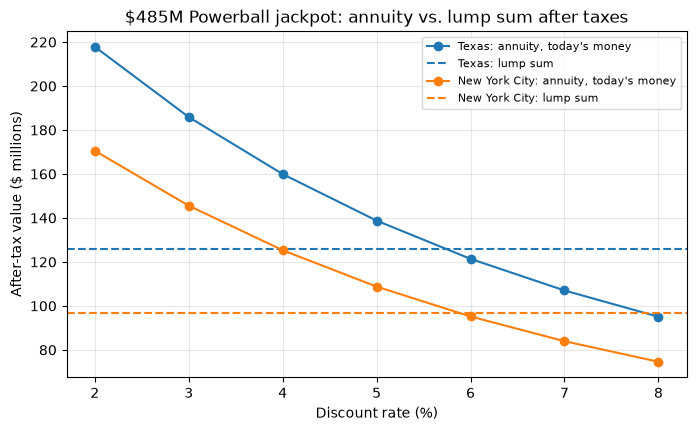

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, state, locality in [('Texas', 'TX', None), ('New York City', 'NY', 'NYC')]:
    flows = annuity_after_tax(state, locality)
    lump_c = cash_c - taxes(cash_c, state, locality)['total']
    line, = ax.plot([r * 100 for r in DISCOUNT_RATES], [present_value(flows, r) / 1e8 for r in DISCOUNT_RATES], marker='o', label=f'{name}: annuity, today\'s money')
    ax.axhline(lump_c / 1e8, color=line.get_color(), linestyle='--', label=f'{name}: lump sum')
ax.set_xlabel('Discount rate (%)')
ax.set_ylabel('After-tax value ($ millions)')
ax.set_title(f'${JACKPOT / 1e6:,.0f}M Powerball jackpot: annuity vs. lump sum after taxes')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 4. Check against the calculator

With the default parameters ($485M jackpot, $199.8M cash, single, no other income), these are the figures the [Powerball calculator](https://jackpotcalculator.com/powerball-calculator/) produced on October 7, 2026. The cell fails if the notebook drifts from them.

In [9]:
if (JACKPOT, CASH_VALUE, STATUS, OTHER_INCOME) == (485_000_000, 199_800_000, 'single', 0):
    expected = {('TX', None): (125_924_000_00, 307_049_993_00), ('NY', None): (104_361_086_00, 258_982_322_00),
                ('NY', 'NYC'): (96_616_963_00, 240_187_469_00), ('IL', None): (116_033_900_00, 283_042_493_00)}
    for (state, locality), (lump_exp, annuity_exp) in expected.items():
        assert cash_c - taxes(cash_c, state, locality)['total'] == lump_exp, (state, locality)
        assert sum(annuity_after_tax(state, locality)) == annuity_exp, (state, locality)
    print('Matches the calculator to the cent.')
else:
    print('Custom parameters: compare with https://jackpotcalculator.com/powerball-calculator/')

Matches the calculator to the cent.


---
Data: [lottery tax by state (2026)](https://github.com/jiankn/lottery-tax-by-state), CC BY 4.0, by [Jackpot Calculator](https://jackpotcalculator.com/). Withholding rates link to each state's official source. Corrections are logged in the [methodology](https://jackpotcalculator.com/methodology/#changes).